In [1]:
!pip install anndata==0.8.0

In [8]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [9]:
def binary_exp(ct, gdict, marker_dict,org_g_dict, gene_ord):
    heatmap = pd.DataFrame(data = np.zeros((len(ct),len(gene_ord))),index = ct, columns = gene_ord)
    for item in ct:
        if item in marker_dict:
            for g in heatmap.columns:
                org_g = org_g_dict[g]
                if org_g in marker_dict[item]:
                    heatmap.loc[item,g] +=1
                if type(org_g) == float:
                    heatmap.loc[item,g] = np.nan
        else:
            heatmap.loc[item,:] = [np.nan for i in range(len(gene_ord))]
    return(heatmap)

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad
import math
import csv

In [2]:
with open('../../parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [3]:
otohomo = pd.read_csv('../../OTO_star_nothreshold_missing_le2_expressionthresh_08022026.tsv', delimiter = '\t',index_col = 'MM')

In [4]:
orthogroups = pd.read_csv('../../Vert_emapper_allorgs_07032026.tsv', delimiter = '\t', index_col = 'Unnamed: 0')

In [5]:
with open('../../Important_genes/MO_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/MO_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_mo = pickle.load(f)
    
with open('../../Important_genes/CJ_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/CJ_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_cj = pickle.load(f)
    
with open('../../Important_genes/AC_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/AC_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_ac = pickle.load(f)
    
with open('../../Important_genes/XT_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/XT_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_xt = pickle.load(f)
    
with open('../../Important_genes/DR_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/DR_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_dr = pickle.load(f)
    
with open('../../Important_genes/MM_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026/MM_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026.pkl', 'rb') as f:
    marker_dict_mg = pickle.load(f)

In [10]:
mm_mapping_ortho = orthogroup_mapper(orthogroups,'MM')
mo_mapping_ortho = orthogroup_mapper(orthogroups,'MO')
cj_mapping_ortho = orthogroup_mapper(orthogroups,'CJ')
ac_mapping_ortho = orthogroup_mapper(orthogroups,'AC')
xt_mapping_ortho = orthogroup_mapper(orthogroups,'XT')
dr_mapping_ortho = orthogroup_mapper(orthogroups,'DR')

In [11]:
neuropep = pd.read_csv('../../Neuropeptides_receptors_10202025.csv')

In [12]:
neuropep

,Neuropeptide names,Receptors,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Adcyap1,Adcyap1r1,Vipr1,Vipr2,NaN,NaN,NaN
1,Adm,Calcr,NaN,NaN,NaN,NaN,NaN
2,Adm2,NaN,NaN,NaN,NaN,NaN,NaN
3,Agrp,Mc3r,Mc4r,NaN,NaN,NaN,NaN
4,Agt,Agtr1a,Agtr2,Agtr1b,NaN,NaN,NaN
...,...,...,...,...,...,...,...
90,Gnas,NaN,NaN,NaN,NaN,NaN,NaN
91,Enho,Grp19,NaN,NaN,NaN,NaN,NaN
92,Cgrp,Calcr,NaN,NaN,NaN,NaN,NaN
93,Dbi,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
R_set = set(neuropep.columns) - set(['Neuropeptide names'])

In [14]:
receptors = set(np.unique([str(x).strip() for x in neuropep[R_set].values.ravel() if pd.notna(x)]))

In [15]:
receptors

{'Adcyap1r1',
 'Adipor1',
 'Adipor2',
 'Agtr1a',
 'Agtr1b',
 'Agtr2',
 'Aplnr',
 'Avp2r',
 'Avpr1a',
 'Avpr1b',
 'Bdkrb1',
 'Bdkrb2',
 'Brs3',
 'C3ar1',
 'Calcr',
 'Cckar',
 'Cckbr',
 'Crhr1',
 'Crhr2',
 'Ednra',
 'Ednrb',
 'Galr1',
 'Galr2',
 'Galr3',
 'Gcgr',
 'Ghrhr',
 'Gipr',
 'Glp1r',
 'Gnrhr',
 'Gpr68',
 'Grp19',
 'Grpr',
 'Gshr1a',
 'Hcrtr1',
 'Hcrtr2',
 'Igf1r',
 'Igf2r',
 'Insr',
 'Kiss1r',
 'Lepr',
 'Mc1r',
 'Mc3r',
 'Mc4r',
 'Mc5r',
 'Mchr1',
 'Mchr2',
 'Mlnr',
 'Nmbr',
 'Nmur1',
 'Nmur2',
 'Npbwr1',
 'Npbwr2',
 'Npffr1',
 'Npffr2',
 'Npr1',
 'Npr2',
 'Npr3',
 'Npsr1',
 'Npy1r',
 'Npy2r',
 'Npy4r',
 'Npyr',
 'Nr3c1',
 'Ntsr1',
 'Ntsr2',
 'Oprd1',
 'Oprk1',
 'Oprl1',
 'Oprm1',
 'Oxtr',
 'Prlhr',
 'Prlr',
 'Prokr1',
 'Prokr2',
 'Pth1r',
 'Qrfpr',
 'Rxfp1',
 'Rxfp2',
 'Rxfp3',
 'Sctr',
 'Sstr1',
 'Sstr2',
 'Sstr3',
 'Sstr4',
 'Sstr5',
 'Tacr1',
 'Tacr2',
 'Tacr3',
 'Trhr',
 'Uts2r',
 'Vipr1',
 'Vipr2'}

In [16]:
receptors = list(receptors)
neuropeptides = list(set(neuropep['Neuropeptide names']))

In [17]:
all_np = neuropeptides + receptors

In [18]:
len(receptors)

92

In [19]:
overall_NP_set = set(otohomo.index) & set(all_np)

In [20]:
mg_exp ={i:i for i in overall_NP_set}
mo_exp = {i:otohomo.loc[i,'MO'] for i in overall_NP_set}
cj_exp = {i:otohomo.loc[i,'CJ'] for i in overall_NP_set}
ac_exp = {i:otohomo.loc[i,'AC'] for i in overall_NP_set}
xt_exp = {i:otohomo.loc[i,'XT'] for i in overall_NP_set}
dr_exp = {i:otohomo.loc[i,'DR'] for i in overall_NP_set}

In [21]:
set(mg_exp.keys()) - set(mo_exp.keys())

set()

In [22]:
hypo_names = [i for i in marker_dict_mg.keys() if parent_dict[parent_dict[i]] == 'hypo']
hypo_names.sort()

In [23]:
fixed_gene_ord = list(mg_exp.keys())
bi_mg = binary_exp(hypo_names,mg_exp,marker_dict_mg,mg_exp,fixed_gene_ord)
bi_mo = binary_exp(hypo_names,mg_exp,marker_dict_mo,mo_exp,fixed_gene_ord)
bi_cj = binary_exp(hypo_names,mg_exp,marker_dict_cj,cj_exp,fixed_gene_ord)
bi_ac = binary_exp(hypo_names,mg_exp,marker_dict_ac,ac_exp,fixed_gene_ord)
bi_xt = binary_exp(hypo_names,mg_exp,marker_dict_xt,xt_exp,fixed_gene_ord)
bi_dr = binary_exp(hypo_names,mg_exp,marker_dict_dr,dr_exp,fixed_gene_ord)

In [24]:
bi_xt.shape

(73, 143)

In [25]:
bi_xt.loc[:,'Pomc']

066 NDB-SI-ant Prdm12 Gaba     NaN
073 MEA-BST Sox6 Gaba          0.0
074 MEA-BST Lhx6 Sp9 Gaba      0.0
075 MEA-BST Lhx6 Nr2e1 Gaba    NaN
076 MEA-BST Lhx6 Nfib Gaba     NaN
                              ... 
140 PMd-LHA Foxb1 Glut         0.0
141 PH-SUM Foxa1 Glut          0.0
142 HY Gnrh1 Glut              NaN
143 MM-ant Foxb1 Glut          0.0
144 MM Foxb1 Glut              NaN
Name: Pomc, Length: 73, dtype: float64

In [26]:
cmap = plt.cm.Blues.copy()
cmap.set_bad(color="lightgray")  # color for NaNs

<AxesSubplot:>

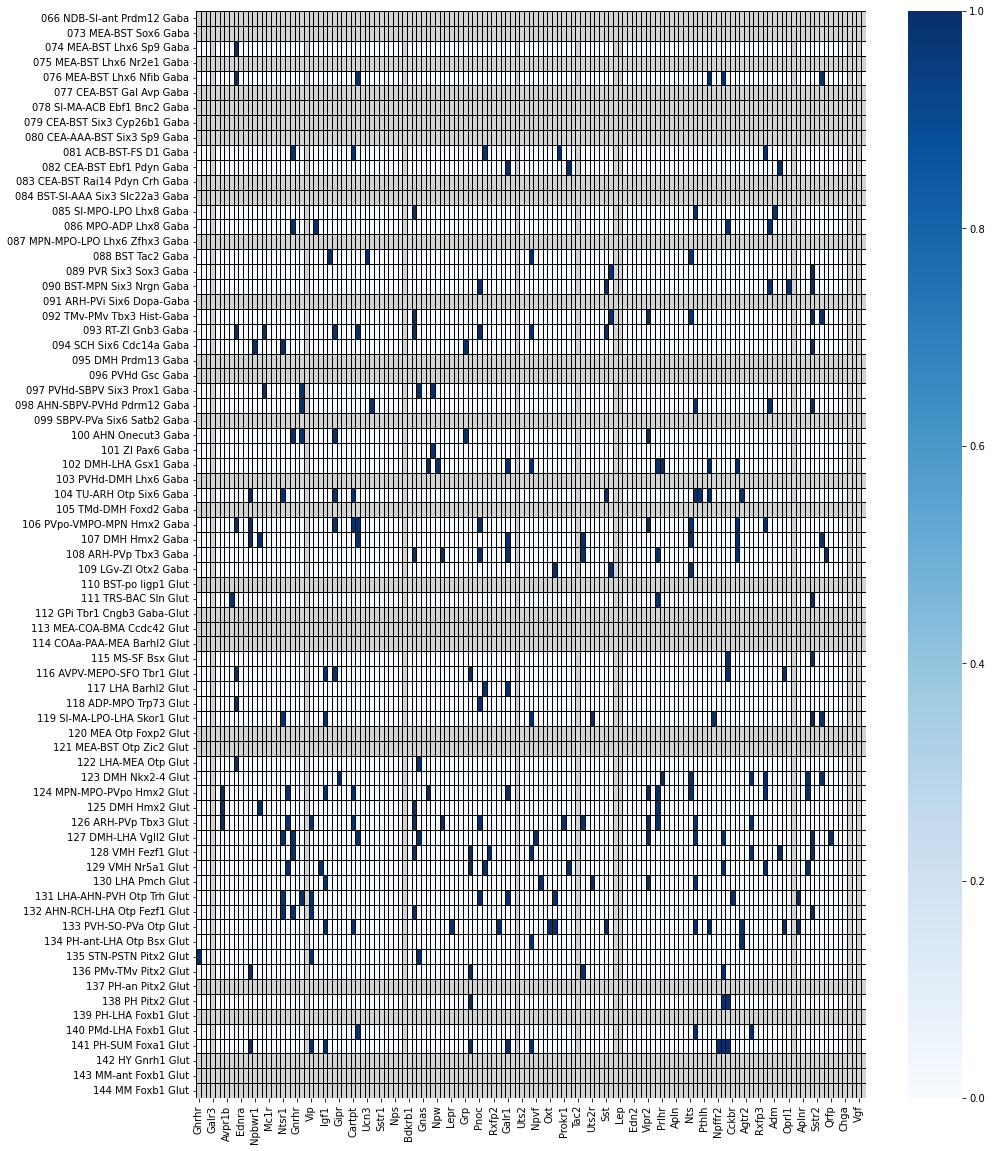

In [27]:
plt.figure(figsize=(15,20))
sns.heatmap(bi_cj, cmap = cmap,  linewidth=0.5, linecolor='black',)

In [28]:
fbi_mg = bi_mg.fillna(0)
fbi_mo = bi_mo.fillna(0)
fbi_cj = bi_cj.fillna(0)
fbi_ac = bi_ac.fillna(0)
fbi_xt = bi_xt.fillna(0)
fbi_dr = bi_dr.fillna(0)

In [29]:
fbi_all = fbi_mg + fbi_mo + fbi_cj + fbi_ac + fbi_xt + fbi_dr

In [30]:
'Crh' in fbi_all.columns

True

In [31]:
fbi_all

,Ghrhr,Ucn,Galr2,Galr3,Bdkrb2,Pomc,Avpr1b,Oprd1,Rxfp1,Ednra,...,Ednrb,Prl,Qrfp,Gip,Sstr3,Chga,Hcrt,Igf1r,Vgf,Prlr
066 NDB-SI-ant Prdm12 Gaba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
073 MEA-BST Sox6 Gaba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
074 MEA-BST Lhx6 Sp9 Gaba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
075 MEA-BST Lhx6 Nr2e1 Gaba,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
076 MEA-BST Lhx6 Nfib Gaba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140 PMd-LHA Foxb1 Glut,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
141 PH-SUM Foxa1 Glut,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
142 HY Gnrh1 Glut,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
143 MM-ant Foxb1 Glut,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
num_orgs = pd.DataFrame(data = np.zeros((len(fbi_all.index),1)),columns = ['Num orgs'], index = fbi_all.index)
for item in num_orgs.index:
    if item in marker_dict_mg.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_mo.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_cj.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_ac.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_xt.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_dr.keys():
        num_orgs.loc[item,'Num orgs'] +=1

In [33]:
cts = num_orgs[num_orgs['Num orgs'] >= 4].index

In [34]:
np.sum(fbi_all, axis = 0)

Ghrhr      6.0
Ucn        2.0
Galr2      6.0
Galr3      9.0
Bdkrb2     0.0
          ... 
Chga       6.0
Hcrt       4.0
Igf1r      1.0
Vgf       16.0
Prlr      32.0
Length: 143, dtype: float64

In [35]:
fbi_all = fbi_all.loc[cts,:]

In [36]:
fbi_all.loc[:,'Pomc']

073 MEA-BST Sox6 Gaba             0.0
074 MEA-BST Lhx6 Sp9 Gaba         0.0
076 MEA-BST Lhx6 Nfib Gaba        0.0
079 CEA-BST Six3 Cyp26b1 Gaba     0.0
082 CEA-BST Ebf1 Pdyn Gaba        0.0
085 SI-MPO-LPO Lhx8 Gaba          0.0
086 MPO-ADP Lhx8 Gaba             0.0
088 BST Tac2 Gaba                 0.0
089 PVR Six3 Sox3 Gaba            0.0
090 BST-MPN Six3 Nrgn Gaba        0.0
091 ARH-PVi Six6 Dopa-Gaba        0.0
092 TMv-PMv Tbx3 Hist-Gaba        0.0
093 RT-ZI Gnb3 Gaba               0.0
094 SCH Six6 Cdc14a Gaba          0.0
097 PVHd-SBPV Six3 Prox1 Gaba     0.0
098 AHN-SBPV-PVHd Pdrm12 Gaba     0.0
100 AHN Onecut3 Gaba              0.0
101 ZI Pax6 Gaba                  0.0
102 DMH-LHA Gsx1 Gaba             0.0
104 TU-ARH Otp Six6 Gaba          0.0
105 TMd-DMH Foxd2 Gaba            0.0
106 PVpo-VMPO-MPN Hmx2 Gaba       1.0
107 DMH Hmx2 Gaba                 0.0
108 ARH-PVp Tbx3 Gaba             0.0
111 TRS-BAC Sln Glut              0.0
115 MS-SF Bsx Glut                0.0
116 AVPV-MEP

In [37]:
total_index = fbi_all.columns[(fbi_all >= 4).any(axis=0)]

In [38]:
len(total_index)

22

In [39]:
total_index

Index(['Igf1', 'Npy', 'Grp', 'Adcyap1', 'Pnoc', 'Avp', 'Galr1', 'Npvf', 'Pmch',
       'Oxt', 'Sst', 'Glp1r', 'Crh', 'Nts', 'Agrp', 'Gal', 'Oprk1', 'Agtr1a',
       'Trh', 'Pdyn', 'Qrfp', 'Hcrt'],
      dtype='object')

In [41]:
column_map = pd.DataFrame(index = fbi_all.columns, columns = ['npcolor'])
for item in fbi_all.columns:
    if item in neuropeptides:
        column_map.loc[item,'npcolor'] = 'Purple'
    else:
        column_map.loc[item,'npcolor'] = 'Green'

In [42]:
fbi_all.shape

(48, 143)

In [40]:
mg_np = []
mo_np = []
cj_np = []
ac_np= []
xt_np = []
dr_np = []
for item in fbi_all.columns:
    mg_np.append(mg_exp[item])
    mo_np.append(mo_exp[item])
    cj_np.append(cj_exp[item])
    ac_np.append(ac_exp[item])
    xt_np.append(xt_exp[item])
    dr_np.append(dr_exp[item])

In [42]:
with open("../../mg_np_all_08022026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(mg_np)  
    
with open("../../mo_np_all_08022026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(mo_np)  
    
with open("../../cj_np_all_08022026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(cj_np)  
    
with open("../../ac_np_all_08022026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(ac_np)  
    
with open("../../xt_np_all_08022026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(xt_np)  
    
with open("../../dr_np_all_08022026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(dr_np)  

In [136]:
fbi_all.columns

Index(['Gnrh1', 'Gcg', 'Npbwr1', 'Rxfp2', 'Aplnr', 'Tac2', 'Npy4r', 'Sstr3',
       'Oxt', 'Oprk1',
       ...
       'Adm', 'Avpr1a', 'Prlhr', 'Sstr2', 'Igf1r', 'Agrp', 'Prok1', 'Ghrl',
       'Igf1', 'Npb'],
      dtype='object', length=143)

In [137]:
np_mapping = pd.DataFrame(data = [list(fbi_all.columns),
                     [mo_exp[i] for i in list(fbi_all.columns)],
                     [cj_exp[i]for i in list(fbi_all.columns)],
                     [ac_exp[i] for i in list(fbi_all.columns)],
                     [xt_exp[i] for i in list(fbi_all.columns)],
                     [dr_exp[i] for i in list(fbi_all.columns)]],
             index = ['Mouse gene name','Vole gene name','Quail gene name','Anole gene name','Xenopus gene name','Zebrafish gene name']).T

In [138]:
np_mapping.to_csv('../../NP_mapping_allorgs_Fig2_08022026.csv')

In [43]:
old_set = ['Pomc','Hcrt','Npvf','Qrfp','Adcyap1','Pdyn','Oprk1','Igf1','Pmch','Trh','Agtr1a','Oxt','Avp','Crh']

In [44]:
old_set.reverse()

In [45]:
old_set

['Crh',
 'Avp',
 'Oxt',
 'Agtr1a',
 'Trh',
 'Pmch',
 'Igf1',
 'Oprk1',
 'Pdyn',
 'Adcyap1',
 'Qrfp',
 'Npvf',
 'Hcrt',
 'Pomc']

In [46]:
reindex = ['Grp','Nts','Pnoc','Gal','Galr1','Agrp','Npy','Sst','Glp1r'] + old_set

In [47]:
otohomo.loc[reindex,:]

,MO,CJ,AC,XT,DR,n_species
MM,,,,,,
Grp,Grp,GRP,grp,grp,NaN,5
Nts,Nts,NTS,nts,nts,nts,6
Pnoc,Pnoc,ENSCJPG00005013002,pnoc,pnoc,pnoca,6
Gal,Gal,GAL,gal,ENSXETG00000044443,gal,6
Galr1,Galr1,GALR1,galr1,galr1,galr1a,6
Agrp,Agrp,Agrp,agrp,agrp,agrp,6
Npy,Npy,NPY,npy,npy,npy,6
Sst,Sst,SST,sst,sst.1,sst1.1,6
Glp1r,Glp1r,GLP1R,glp1r,glp1r,NaN,5


In [48]:
reindex

['Grp',
 'Nts',
 'Pnoc',
 'Gal',
 'Galr1',
 'Agrp',
 'Npy',
 'Sst',
 'Glp1r',
 'Crh',
 'Avp',
 'Oxt',
 'Agtr1a',
 'Trh',
 'Pmch',
 'Igf1',
 'Oprk1',
 'Pdyn',
 'Adcyap1',
 'Qrfp',
 'Npvf',
 'Hcrt',
 'Pomc']

In [49]:
set(reindex) - set(fbi_all.columns)

set()

In [50]:
set(total_index) - set(reindex)

set()

In [51]:
set(reindex) - set(total_index)

{'Pomc'}

In [52]:
fbi_all = fbi_all.loc[:,reindex]

In [55]:
len(fbi_all.index)

48

In [58]:
fbi_all[(fbi_all >= 2).any(axis=1)]

,Grp,Nts,Pnoc,Gal,Galr1,Agrp,Npy,Sst,Glp1r,Crh,...,Trh,Pmch,Igf1,Oprk1,Pdyn,Adcyap1,Qrfp,Npvf,Hcrt,Pomc
073 MEA-BST Sox6 Gaba,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
074 MEA-BST Lhx6 Sp9 Gaba,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
076 MEA-BST Lhx6 Nfib Gaba,0.0,0.0,1.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
082 CEA-BST Ebf1 Pdyn Gaba,0.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
085 SI-MPO-LPO Lhx8 Gaba,0.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
086 MPO-ADP Lhx8 Gaba,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
088 BST Tac2 Gaba,1.0,3.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
090 BST-MPN Six3 Nrgn Gaba,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
092 TMv-PMv Tbx3 Hist-Gaba,0.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
093 RT-ZI Gnb3 Gaba,0.0,1.0,4.0,0.0,1.0,0.0,4.0,4.0,1.0,0.0,...,2.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


<AxesSubplot:>

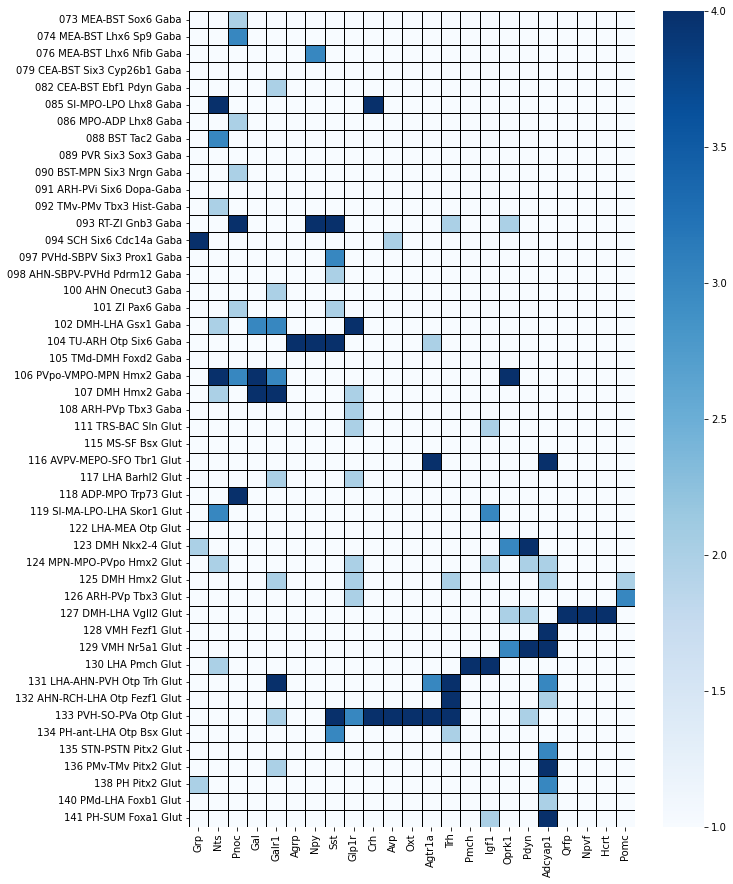

In [60]:
plt.figure(figsize=(10,15))
sns.heatmap(fbi_all, cmap = cmap,  linewidth=0.5, linecolor='black',vmax = 4, vmin = 1)

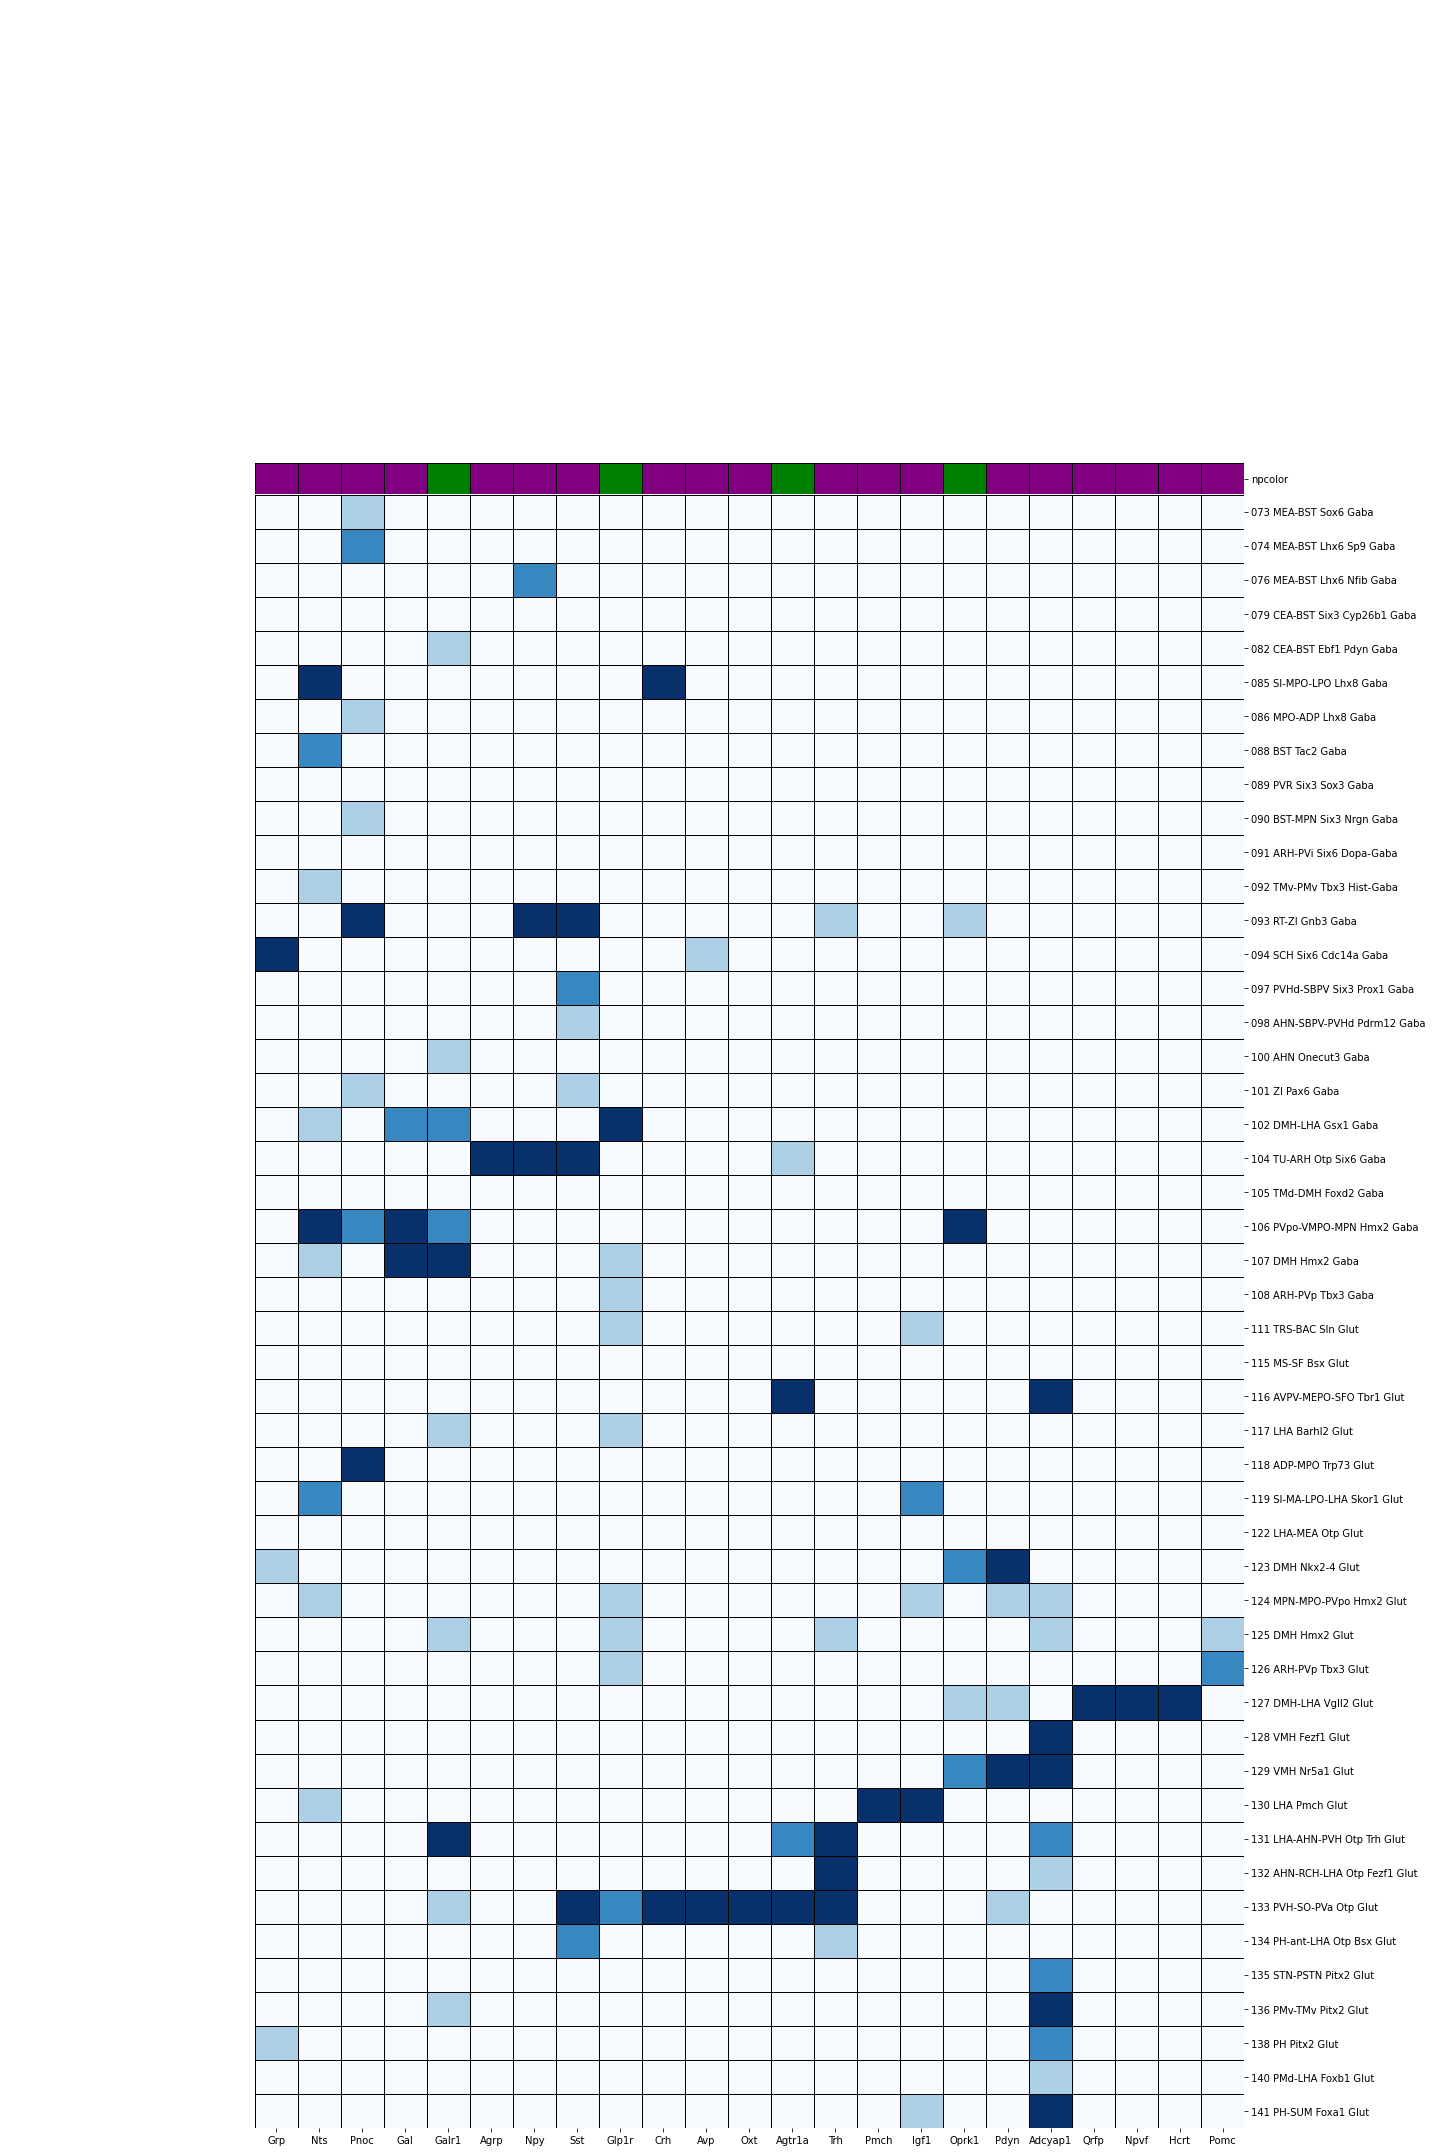

In [150]:
g = sns.clustermap(fbi_all, cmap = cmap,  linewidth=1, linecolor='black',vmax = 4, vmin = 1,col_colors = column_map, row_cluster = False, col_cluster = False, figsize = (20,30), cbar_pos = None)
#g.ax_heatmap.set_xticks([])
#g.ax_heatmap.set_yticks([])
colc_ax = g.ax_col_colors
box = colc_ax.get_position()
colc_ax.set_position([
    box.x0,              # left
    box.y0,       # bottom (shift it up a bit)
    box.width,           # keep width
    box.height * .5    # reduce height (30% of original)
])

plt.savefig('../../Figures/Figures_08022026/Neuropeptide_marker_conservation_missingtwo_08022026.png', dpi = 300,bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_08022026/Neuropeptide_marker_conservation_missingtwo_08022026.svg',bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_08022026/Neuropeptide_marker_conservation_missingtwo_08022026.pdf',bbox_inches = 'tight')